<a href="https://colab.research.google.com/github/AndrasBajnokSzabo/kaggle-petfinder-adoption-prediction/blob/main/notebooks/Kaggle_petfinder_data_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files

# This will prompt you to select a file. Choose the kaggle.json you downloaded.
files.upload()

# Set up the Kaggle directory and permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download and unzip the PetFinder dataset
!kaggle competitions download -c petfinder-adoption-prediction
!unzip -q petfinder-adoption-prediction.zip

Saving kaggle.json to kaggle (2).json
100% 1.94G/1.94G [00:21<00:00, 97.8MB/s]



In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the training CSV
df = pd.read_csv('train/train.csv')

# Display the first few rows to verify
display(df.head())

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,...,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,...,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,...,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,...,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


/tmp/ipykernel_1409/562014491.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Type', palette='Set2', ax=axes[0])


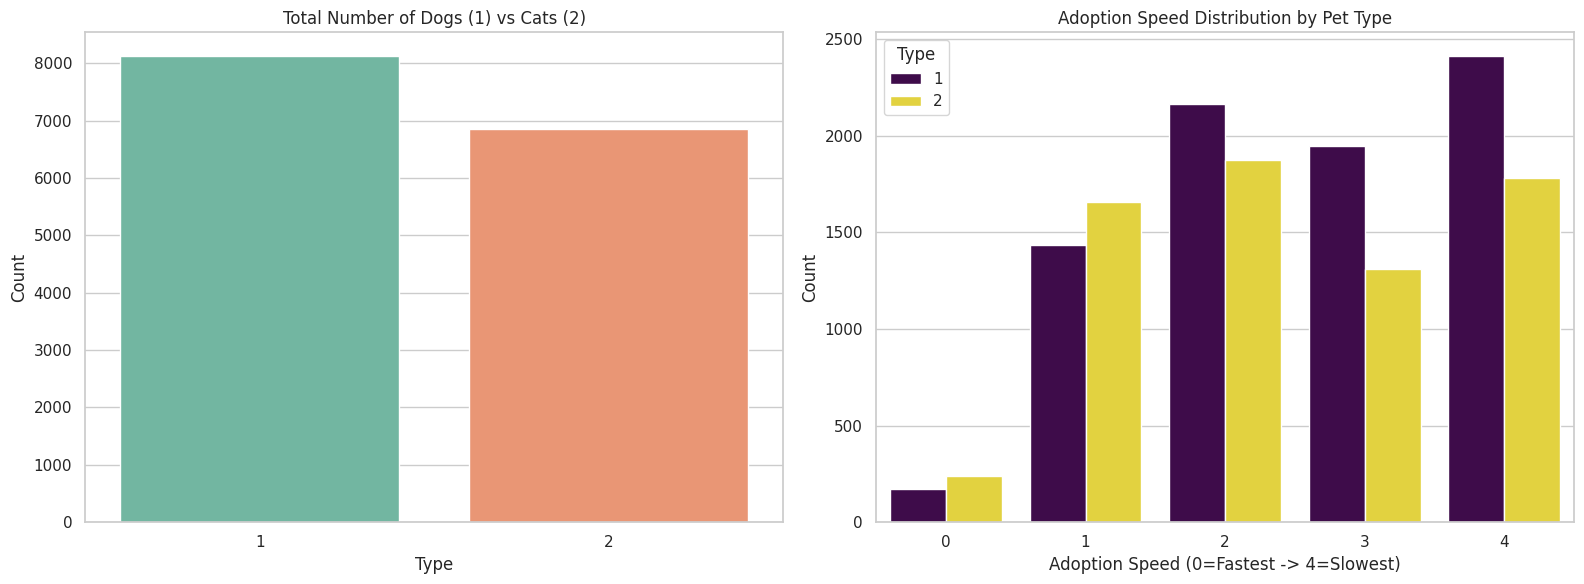

In [5]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Total Dogs vs Cats (Type 1 = Dog, Type 2 = Cat)
sns.countplot(data=df, x='Type', palette='Set2', ax=axes[0])
axes[0].set_title('Total Number of Dogs (1) vs Cats (2)')
axes[0].set_ylabel('Count')

# Plot 2: Adoption Speed Distribution
# AdoptionSpeed: 0 (Fastest) to 4 (Not Adopted)
sns.countplot(data=df, x='AdoptionSpeed', hue='Type', palette='viridis', ax=axes[1])
axes[1].set_title('Adoption Speed Distribution by Pet Type')
axes[1].set_xlabel('Adoption Speed (0=Fastest -> 4=Slowest)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()